In [1345]:
import pandas as pd
import seaborn as srn
import statistics as sts
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, skewnorm

In [1346]:
df = pd.read_csv("StudentsPerformance.csv", sep=',')
display (df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [1347]:
df.columns = ['genero','raca/etnia','nivel da educacao familiar','almoco','curso de preparacao','nota em matematica','nota em leitura','nota em escrita']
display(df)

,genero,raca/etnia,nivel da educacao familiar,almoco,curso de preparacao,nota em matematica,nota em leitura,nota em escrita
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [1348]:
#Analisando os tipos de genero e suas quantidades
agrupado = df.groupby(df['genero']).size()
agrupado

genero
female    518
male      482
dtype: int64

In [1349]:
#Vendo o genero mais presente no arquivo
moda = sts.mode(df['genero'])
moda

'female'

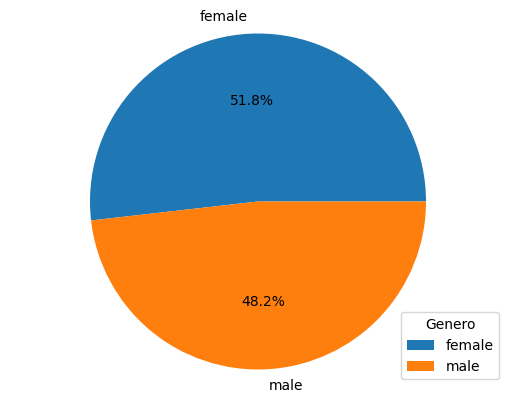

In [1350]:
# Gerando gráfico de pizza para uma comparação entre os dois gêneros
plt.pie(agrupado,labels= ['female','male'],autopct='%1.1f%%')
plt.legend(title='Genero',loc="lower right")
plt.axis('equal')
plt.show()

In [1351]:
#Realizando o estudo das notas de acordo com algum padrão.
a= df.groupby('genero')['nota em matematica'].mean()
b= df.groupby('genero')['nota em leitura'].mean()
c= df.groupby('genero')['nota em escrita'].mean()
display("Medias das Notas em matematica por genero", a)# Homens com nota maior
display("Medias das Notas em leitura por genero", b)#Mulheres com nota maior
display("Medias das Notas em escrita por genero", c)#Mulheres com nota maior

'Medias das Notas em matematica por genero'

genero
female    63.633205
male      68.728216
Name: nota em matematica, dtype: float64

'Medias das Notas em leitura por genero'

genero
female    72.608108
male      65.473029
Name: nota em leitura, dtype: float64

'Medias das Notas em escrita por genero'

genero
female    72.467181
male      63.311203
Name: nota em escrita, dtype: float64

In [1352]:
#Achando os intervalos de confiança das notas para jogar nos gráficos

dpr= df.groupby('genero')['nota em matematica'].std(ddof=1) #desvio padrao das notas por genero
ic_supm = a + (1.96*dpr/(1000**(1/2)))
ic_infm = a - (1.96*dpr/(1000**(1/2)))
print(ic_supm)
print(ic_infm)
erro_supm = ic_supm - a #distancia do erro ate a media para ir no grafico
erro_infm = a - ic_infm #distancia do erro ate a media para ir no grafico

dpr= df.groupby('genero')['nota em leitura'].std(ddof=1) #desvio padrao das notas por genero
ic_supl = b + (1.96*dpr/(1000**(1/2)))
ic_infl = b - (1.96*dpr/(1000**(1/2)))
print(ic_supl)
print(ic_infl)
erro_supl = ic_supl - b #distancia do erro ate a media para ir no grafico
erro_infl = b - ic_infl #distancia do erro ate a media para ir no grafico

dpr= df.groupby('genero')['nota em escrita'].std(ddof=1) #desvio padrao das notas por genero
ic_supe = c + (1.96*dpr/(1000**(1/2)))
ic_infe = c - (1.96*dpr/(1000**(1/2)))
print(ic_supe)
print(ic_infe)
erro_supe = ic_supe - c #distancia do erro ate a media para ir no grafico
erro_infe = c - ic_infe #distancia do erro ate a media para ir no grafico


genero
female    64.593375
male      69.618027
Name: nota em matematica, dtype: float64
genero
female    62.673034
male      67.838404
Name: nota em matematica, dtype: float64
genero
female    73.499281
male      66.336533
Name: nota em leitura, dtype: float64
genero
female    71.716935
male      64.609525
Name: nota em leitura, dtype: float64
genero
female    73.387274
male      64.185988
Name: nota em escrita, dtype: float64
genero
female    71.547089
male      62.436419
Name: nota em escrita, dtype: float64


C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\2515835522.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='genero', y='nota em matematica',palette=cores,order=ordem, ax=ax)


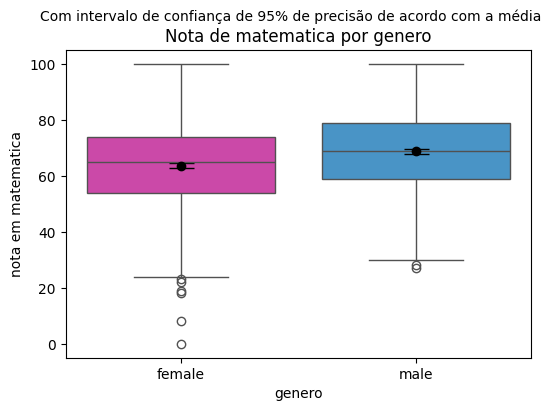

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\2515835522.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='genero', y='nota em leitura',palette=cores,order=ordem, ax=ax)


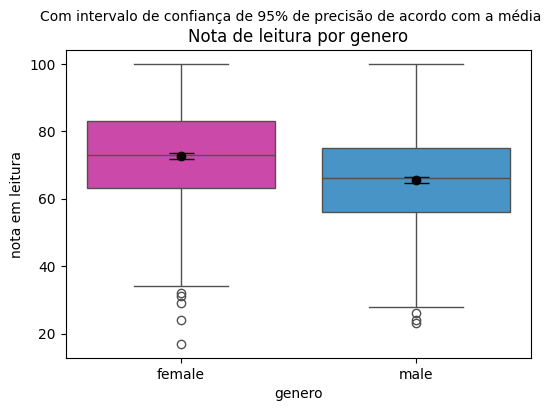

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\2515835522.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='genero', y='nota em escrita',palette=cores,order=ordem, ax=ax)


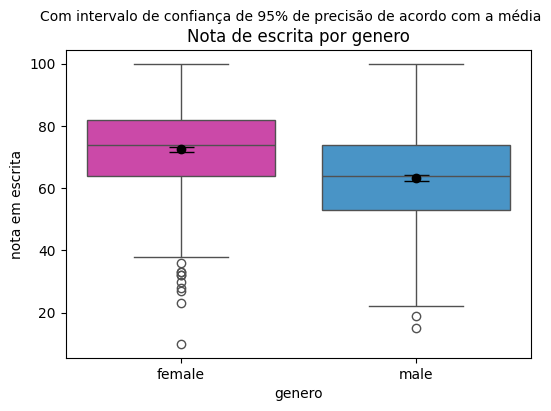

In [1353]:
cores = {
    'male': '#3498db',
    'female': "#e133b2"
}
ordem = ['female','male'] # criado para manter padrão na hora de colocar os intervalos de confiança
fig, ax = plt.subplots(figsize=(6,4))
srn.boxplot(data=df, x='genero', y='nota em matematica',palette=cores,order=ordem, ax=ax)
plt.title("Nota de matematica por genero")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, genero in enumerate(ordem): #percorre genero atraves de valores de i na ordem definida, x=0 -> female, x=1 -> male e assim define o intervalo de confiança
    ax.errorbar(x=i,#genero no momento, 0=female, 1=male
                y=a[genero],#media do genero atual
                yerr=[[erro_infm[genero]],[erro_supm[genero]]],#passando os valores da distância para criar o intervalo de confiança
                fmt='o',#formato do intervalo
                capsize=9,#tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
srn.boxplot(data=df, x='genero', y='nota em leitura',palette=cores,order=ordem, ax=ax)
plt.title("Nota de leitura por genero")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, genero in enumerate(ordem): #percorre genero atraves de valores de i na ordem definida, x=0 -> female, x=1 -> male e assim define o intervalo de confiança
    ax.errorbar(x=i, #genero no momento, 0=female, 1=male
                y=b[genero], #media do genero atual
                yerr=[[erro_infl[genero]],[erro_supl[genero]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
srn.boxplot(data=df, x='genero', y='nota em escrita',palette=cores,order=ordem, ax=ax) 
plt.title("Nota de escrita por genero")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, genero in enumerate(ordem): #percorre genero atraves de valores de i na ordem definida, x=0 -> female, x=1 -> male e assim define o intervalo de confiança
    ax.errorbar(x=i,#genero no momento, 0=female, 1=male
                y=c[genero],#media do genero atual
                yerr=[[erro_infe[genero]],[erro_supe[genero]]],#passando os valores da distância para criar o intervalo de confiança
                fmt='o',#formato do intervalo
                capsize=9,#tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

In [1354]:
#Analisando as etinias/raca e suas quantidades
agrupado = df.groupby(df['raca/etnia']).size()
agrupado

raca/etnia
group A     89
group B    190
group C    319
group D    262
group E    140
dtype: int64

In [1355]:
#Vendo a raca/etnia com maior frequência no arquivo
moda = sts.mode(df['raca/etnia'])
moda

'group C'

<Axes: xlabel='raca/etnia'>

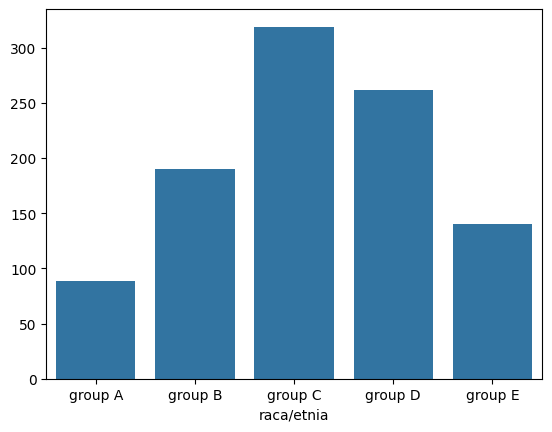

In [1356]:
#Gráfico de barra para uma melhor comparação entre as racas/etnias
srn.barplot(agrupado)

In [1357]:
#Realizando o estudo das notas de acordo com algum padrão.
a = df.groupby('raca/etnia')['nota em matematica'].mean()
b = df.groupby('raca/etnia')['nota em leitura'].mean()
c = df.groupby('raca/etnia')['nota em escrita'].mean()
display(" Medias das Notas em matematica por raca/etnia", a)
display("Medias das Notas em leitura por raca/etnia", b)
display("Medias das Notas em escrita por raca/etnia", c)
#Raca/etnia do grupo E alcançaram maiores notas nas materias, mostrando uma maior facilidade em conseguir estudar

' Medias das Notas em matematica por raca/etnia'

raca/etnia
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: nota em matematica, dtype: float64

'Medias das Notas em leitura por raca/etnia'

raca/etnia
group A    64.674157
group B    67.352632
group C    69.103448
group D    70.030534
group E    73.028571
Name: nota em leitura, dtype: float64

'Medias das Notas em escrita por raca/etnia'

raca/etnia
group A    62.674157
group B    65.600000
group C    67.827586
group D    70.145038
group E    71.407143
Name: nota em escrita, dtype: float64

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1451829445.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.barplot(data=df, x='raca/etnia', y='nota em matematica',palette=cores,order=ordem)


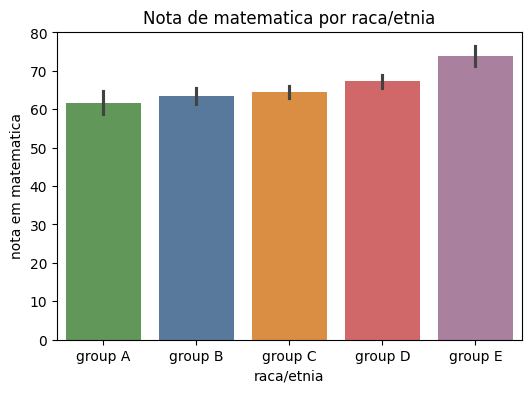

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1451829445.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.barplot(data=df, x='raca/etnia', y='nota em leitura',palette=cores,order=ordem)


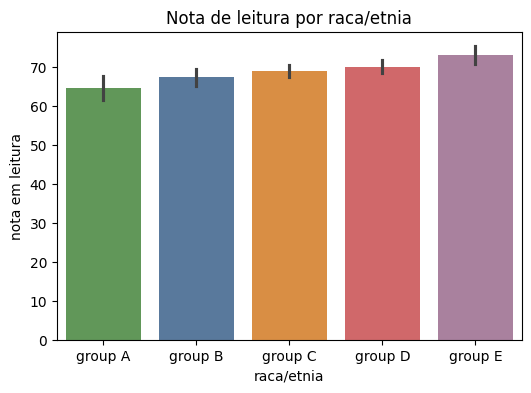

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1451829445.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.barplot(data=df, x='raca/etnia', y='nota em escrita',palette=cores,order=ordem)


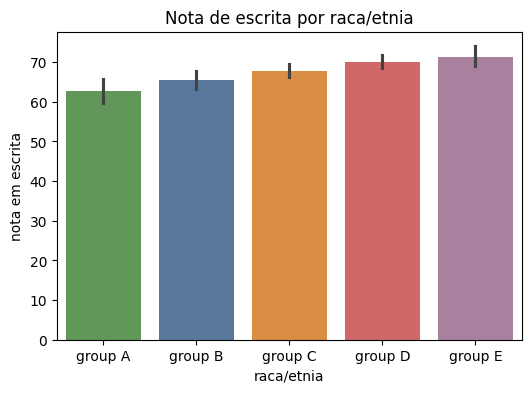

In [1358]:
cores = {
   'group A' : '#59A14F',  # verde
   'group B' : '#4E79A7',  # azul
   'group C' : '#F28E2B',  # laranja
   'group D' : '#E15759',  # vermelho
   'group E' : '#B07AA1'   # roxo
}
ordem= ['group A','group B','group C','group D','group E']
plt.figure(figsize=(6,4))
srn.barplot(data=df, x='raca/etnia', y='nota em matematica',palette=cores,order=ordem)
plt.title("Nota de matematica por raca/etnia")
plt.show()

plt.figure(figsize=(6,4))
srn.barplot(data=df, x='raca/etnia', y='nota em leitura',palette=cores,order=ordem)
plt.title("Nota de leitura por raca/etnia")
plt.show()

plt.figure(figsize=(6,4))
srn.barplot(data=df, x='raca/etnia', y='nota em escrita',palette=cores,order=ordem)
plt.title("Nota de escrita por raca/etnia")
plt.show()

In [1359]:
#Analisando os niveis de educacao familiar
agrupado = df.groupby(df['nivel da educacao familiar']).size()
agrupado

nivel da educacao familiar
associate's degree    222
bachelor's degree     118
high school           196
master's degree        59
some college          226
some high school      179
dtype: int64

In [1360]:
#Vendo o grupo de educação mais presente
moda = sts.mode(df['nivel da educacao familiar'])
moda

'some college'

Text(0.5, 1.0, 'Nivel da Educação Familiar')

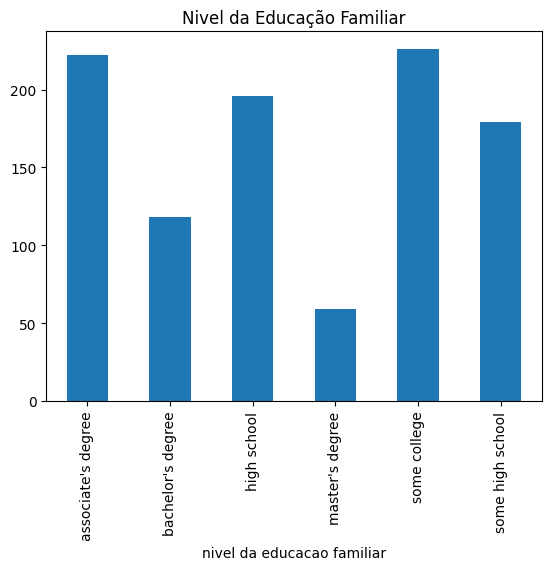

In [1361]:
#Grafico da compração entre os niveis de educação familiar
agrupado.plot.bar()
plt.title("Nivel da Educação Familiar")

In [1362]:
#Realizando o estudo das notas de acordo com algum padrão.
a = df.groupby('nivel da educacao familiar')['nota em matematica'].mean()
b = df.groupby('nivel da educacao familiar')['nota em leitura'].mean()
c = df.groupby('nivel da educacao familiar')['nota em escrita'].mean()
display("Notas em matematica por nivel da educacao familiar", a)
display("Notas em leitura por nivel da educacao familiar", b)
display("Notas em escrita por nivel da educacao familiar", c)
#Nivel de educação Master dos familiares com melhores notas nas provas, mostrando que a educação em casa faz total diferença nos resultados

'Notas em matematica por nivel da educacao familiar'

nivel da educacao familiar
associate's degree    67.882883
bachelor's degree     69.389831
high school           62.137755
master's degree       69.745763
some college          67.128319
some high school      63.497207
Name: nota em matematica, dtype: float64

'Notas em leitura por nivel da educacao familiar'

nivel da educacao familiar
associate's degree    70.927928
bachelor's degree     73.000000
high school           64.704082
master's degree       75.372881
some college          69.460177
some high school      66.938547
Name: nota em leitura, dtype: float64

'Notas em escrita por nivel da educacao familiar'

nivel da educacao familiar
associate's degree    69.896396
bachelor's degree     73.381356
high school           62.448980
master's degree       75.677966
some college          68.840708
some high school      64.888268
Name: nota em escrita, dtype: float64

In [1363]:
#Achando os intervalos de confiança das notas para jogar nos gráficos

dpr= df.groupby('nivel da educacao familiar')['nota em matematica'].std(ddof=1) #desvio padrao das notas por raca/etnia
ic_supm = a + (1.96*dpr/(1000**(1/2)))
ic_infm = a - (1.96*dpr/(1000**(1/2)))
print(ic_supm)
print(ic_infm)
erro_supm = ic_supm - a #distancia do erro ate a media para ir no grafico
erro_infm = a - ic_infm #distancia do erro ate a media para ir no grafico

dpr= df.groupby('nivel da educacao familiar')['nota em leitura'].std(ddof=1) #desvio padrao das notas por raca/etnia
ic_supl = b + (1.96*dpr/(1000**(1/2)))
ic_infl = b - (1.96*dpr/(1000**(1/2)))
print(ic_supl)
print(ic_infl)
erro_supl = ic_supl - b #distancia do erro ate a media para ir no grafico
erro_infl = b - ic_infl #distancia do erro ate a media para ir no grafico

dpr= df.groupby('nivel da educacao familiar')['nota em escrita'].std(ddof=1) #desvio padrao das notas por raca/etnia
ic_supe = c + (1.96*dpr/(1000**(1/2)))
ic_infe = c - (1.96*dpr/(1000**(1/2)))
print(ic_supe)
print(ic_infe)
erro_supe = ic_supe - c #distancia do erro ate a media para ir no grafico
erro_infe = c - ic_infe #distancia do erro ate a media para ir no grafico

nivel da educacao familiar
associate's degree    68.819540
bachelor's degree     70.316056
high school           63.038932
master's degree       70.685012
some college          68.015441
some high school      64.484434
Name: nota em matematica, dtype: float64
nivel da educacao familiar
associate's degree    66.946226
bachelor's degree     68.463605
high school           61.236578
master's degree       68.806513
some college          66.241196
some high school      62.509980
Name: nota em matematica, dtype: float64
nivel da educacao familiar
associate's degree    71.787534
bachelor's degree     73.885409
high school           65.580000
master's degree       76.226675
some college          70.331442
some high school      67.897964
Name: nota em leitura, dtype: float64
nivel da educacao familiar
associate's degree    70.068322
bachelor's degree     72.114591
high school           63.828163
master's degree       74.519088
some college          68.588912
some high school      65.979131
Name

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\3423100921.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em matematica',order=ordem,palette=cores, ax=ax)


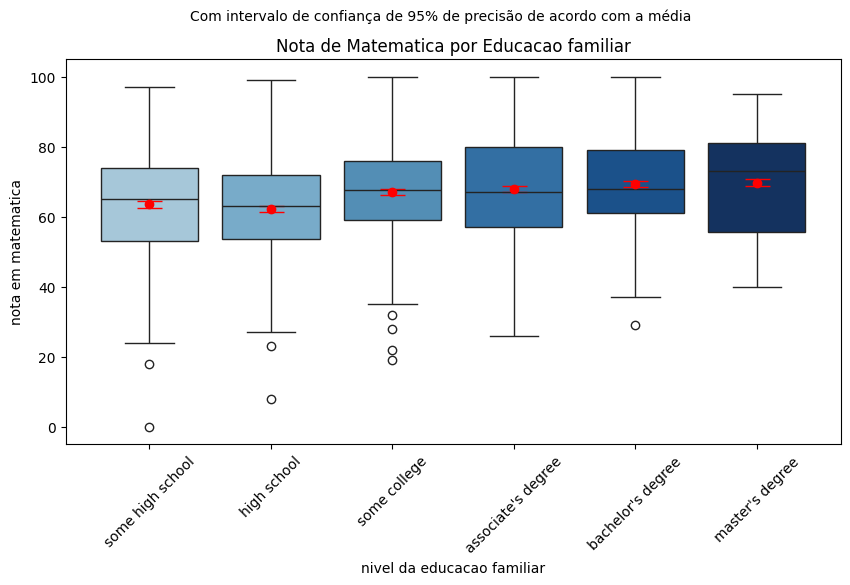

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\3423100921.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em leitura',order=ordem,palette=cores, ax =ax)


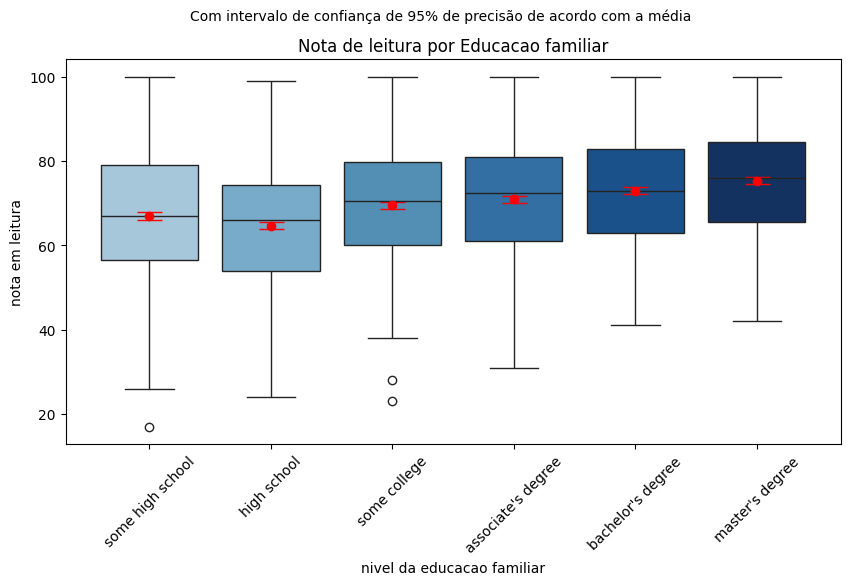

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\3423100921.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em matematica',order=ordem,palette=cores, ax=ax)


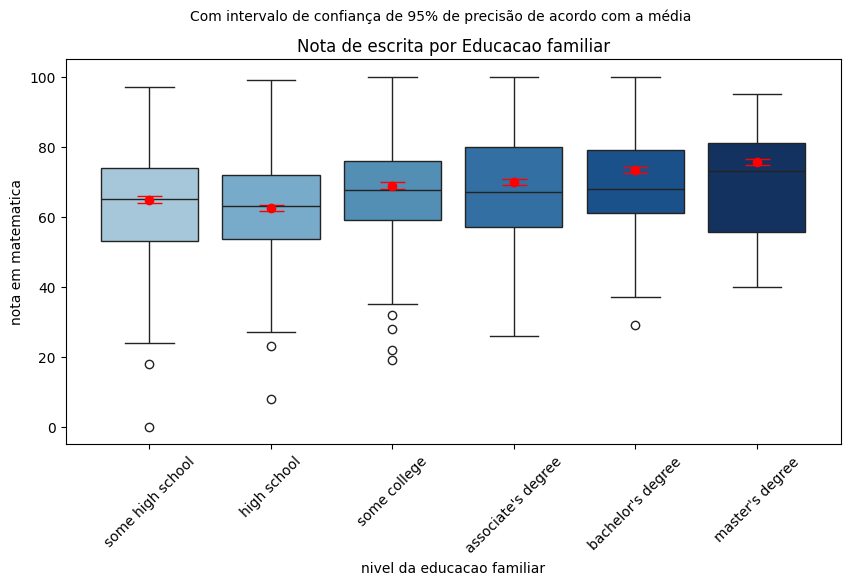

In [1364]:
ordem=['some high school','high school','some college',"associate's degree","bachelor's degree","master's degree"]
cores = {
    'some high school': '#9ecae1',
    'high school': '#6baed6',
    'some college': '#4292c6',
    "associate's degree": '#2171b5',
    "bachelor's degree": '#08519c',
    "master's degree": '#08306b'
   }
   
fig, ax = plt.subplots(figsize=(10,5))
srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em matematica',order=ordem,palette=cores, ax=ax)
plt.title("Nota de Matematica por Educacao familiar")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
plt.xticks(rotation=45)
for i, nivel in enumerate(ordem): #percorre nivel atraves de valores de i na ordem definida, x=0 -> some high, x=1 -> high e assim define o intervalo de confiança
    ax.errorbar(x=i, #nivel no momento
                y=a[nivel], #media do nivel atual
                yerr=[[erro_infm[nivel]],[erro_supm[nivel]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='red')#cores
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em leitura',order=ordem,palette=cores, ax =ax)
plt.title("Nota de leitura por Educacao familiar")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
plt.xticks(rotation=45)
for i, nivel in enumerate(ordem): #percorre nivel atraves de valores de i na ordem definida, x=0 -> some high, x=1 -> high e assim define o intervalo de confiança
    ax.errorbar(x=i, #nivel no momento
                y=b[nivel], #media do nivel atual
                yerr=[[erro_infl[nivel]],[erro_supl[nivel]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='red')#cores
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
srn.boxplot(data=df, x='nivel da educacao familiar', y='nota em matematica',order=ordem,palette=cores, ax=ax)
plt.title("Nota de escrita por Educacao familiar")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
plt.xticks(rotation=45)
for i, nivel in enumerate(ordem): #percorre nivel atraves de valores de i na ordem definida, x=0 -> some high, x=1 -> high e assim define o intervalo de confiança
    ax.errorbar(x=i, #nivel no momento
                y=c[nivel], #media do nivel atual
                yerr=[[erro_infe[nivel]],[erro_supe[nivel]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='red')#cores
plt.show()

In [1365]:
#Analisando se as refeições são padrão ou se foram reduzidas/sem refeição
agrupado = df.groupby(df['almoco']).size()
agrupado

almoco
free/reduced    355
standard        645
dtype: int64

In [1366]:
#Analisando o tipo da refeição mais comum
moda = sts.mode(df['almoco'])
moda

'standard'

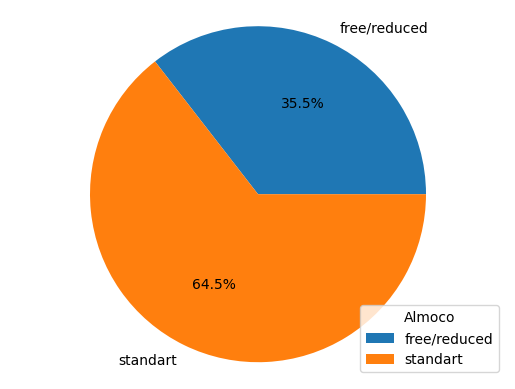

In [1367]:
#Grafico de pizza para melhor entendimento das refeições feitas
plt.pie(agrupado,labels= ['free/reduced','standart'],autopct='%1.1f%%')
plt.legend(title='Almoco',loc="lower right")
plt.axis('equal')
plt.show()

In [1368]:
#Realizando o estudo das notas de acordo com algum padrão.
a= df.groupby('almoco')['nota em matematica'].mean()
b= df.groupby('almoco')['nota em leitura'].mean()
c= df.groupby('almoco')['nota em escrita'].mean()
display("Notas em matematica por tipo de almoco", a)
display("Notas em leitura por tipo de almoco", b)
display("Notas em escrita por tipo de almoco", c)
#Pessoas que mantem uma alimentação diaria boa e tranquila detém de maiores notas

'Notas em matematica por tipo de almoco'

almoco
free/reduced    58.921127
standard        70.034109
Name: nota em matematica, dtype: float64

'Notas em leitura por tipo de almoco'

almoco
free/reduced    64.653521
standard        71.654264
Name: nota em leitura, dtype: float64

'Notas em escrita por tipo de almoco'

almoco
free/reduced    63.022535
standard        70.823256
Name: nota em escrita, dtype: float64

In [1369]:
#Achando os intervalos de confiança das notas para jogar nos gráficos

dpr= df.groupby('almoco')['nota em matematica'].std(ddof=1) #desvio padrao das notas por almoco
ic_supm = a + (1.96*dpr/(1000**(1/2)))
ic_infm = a - (1.96*dpr/(1000**(1/2)))
print(ic_supm)
print(ic_infm)
erro_supm = ic_supm - a #distancia do erro ate a media para ir no grafico
erro_infm = a - ic_infm #distancia do erro ate a media para ir no grafico

dpr= df.groupby('almoco')['nota em leitura'].std(ddof=1) #desvio padrao das notas por almoco
ic_supl = b + (1.96*dpr/(1000**(1/2)))
ic_infl = b - (1.96*dpr/(1000**(1/2)))
print(ic_supl)
print(ic_infl)
erro_supl = ic_supl - b #distancia do erro ate a media para ir no grafico
erro_infl = b - ic_infl #distancia do erro ate a media para ir no grafico

dpr= df.groupby('almoco')['nota em escrita'].std(ddof=1) #desvio padrao das notas poralmoco
ic_supe = c + (1.96*dpr/(1000**(1/2)))
ic_infe = c - (1.96*dpr/(1000**(1/2)))
print(ic_supe)
print(ic_infe)
erro_supe = ic_supe - c #distancia do erro ate a media para ir no grafico
erro_infe = c - ic_infe #distancia do erro ate a media para ir no grafico

almoco
free/reduced    59.860751
standard        70.880361
Name: nota em matematica, dtype: float64
almoco
free/reduced    57.981503
standard        69.187856
Name: nota em matematica, dtype: float64
almoco
free/reduced    65.576744
standard        72.511493
Name: nota em leitura, dtype: float64
almoco
free/reduced    63.730298
standard        70.797034
Name: nota em leitura, dtype: float64
almoco
free/reduced    63.979133
standard        71.712026
Name: nota em escrita, dtype: float64
almoco
free/reduced    62.065937
standard        69.934485
Name: nota em escrita, dtype: float64


C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1354152819.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='almoco', y='nota em matematica',palette=cores,order=ordem, ax=ax)


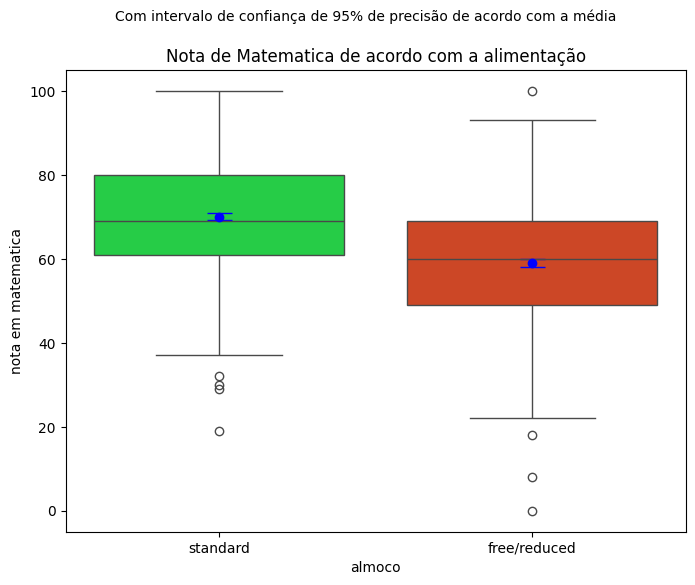

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1354152819.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='almoco', y='nota em leitura',palette=cores,order=ordem,ax=ax)


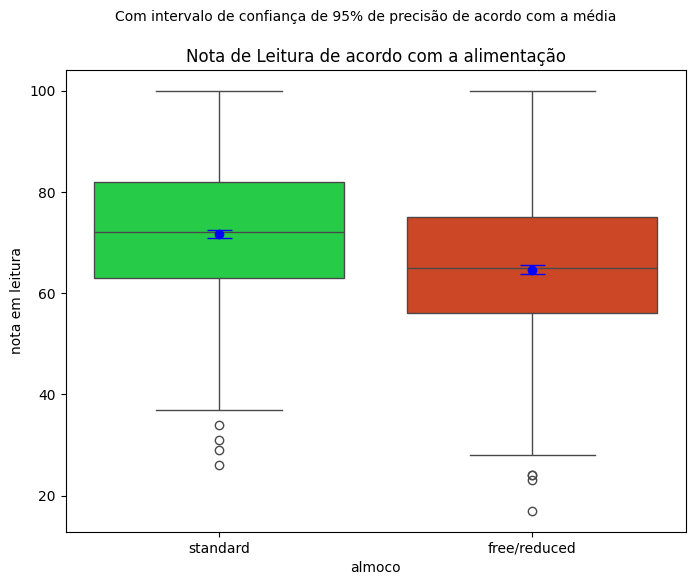

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\1354152819.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='almoco', y='nota em escrita',palette=cores,order=ordem,ax=ax)


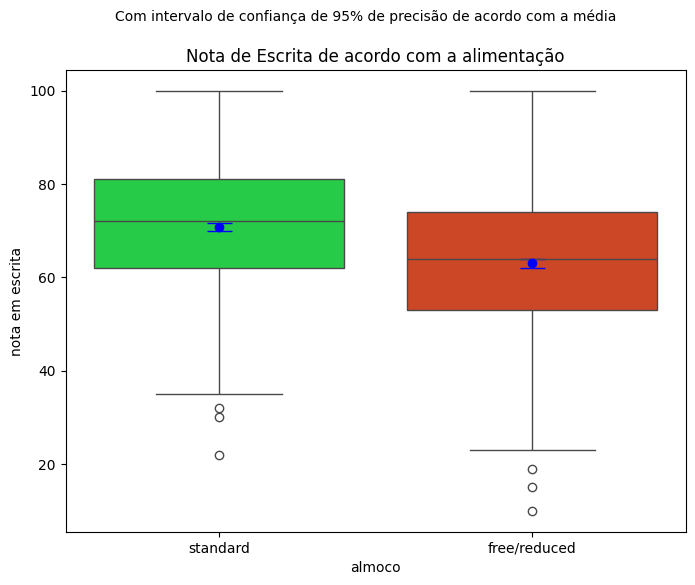

In [1370]:
ordem = ['standard','free/reduced']
cores={
    'standard': "#0ae836",
    'free/reduced': "#e8360a"
}

fig, ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='almoco', y='nota em matematica',palette=cores,order=ordem, ax=ax)
plt.title("Nota de Matematica de acordo com a alimentação")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, alimento in enumerate(ordem): #percorre alimentação atraves de valores de i na ordem definida, x=0 -> standard, x=1 -> free/reduced e assim define o intervalo de confiança
    ax.errorbar(x=i, #alimentação no momento
                y=a[alimento], #media da alimentacao atual
                yerr=[[erro_infm[alimento]],[erro_supm[alimento]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='blue')#cores
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='almoco', y='nota em leitura',palette=cores,order=ordem,ax=ax)
plt.title("Nota de Leitura de acordo com a alimentação")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, alimento in enumerate(ordem): #percorre alimentação atraves de valores de i na ordem definida, x=0 -> standard, x=1 -> free/reduced e assim define o intervalo de confiança
    ax.errorbar(x=i, #alimentação no momento
                y=b[alimento], #media da alimentacao atual
                yerr=[[erro_infl[alimento]],[erro_supl[alimento]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='blue')#cores
plt.show()

fig,ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='almoco', y='nota em escrita',palette=cores,order=ordem,ax=ax)
plt.title("Nota de Escrita de acordo com a alimentação")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, alimento in enumerate(ordem): #percorre alimentação atraves de valores de i na ordem definida, x=0 -> standard, x=1 -> free/reduced e assim define o intervalo de confiança
    ax.errorbar(x=i, #alimentação no momento
                y=c[alimento], #media da alimentacao atual
                yerr=[[erro_infe[alimento]],[erro_supe[alimento]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='blue')#cores
plt.show()

In [1371]:
#Analisando se teve ou não um curso de preparação para a realização das provas
agrupado = df.groupby(df['curso de preparacao']).size()
agrupado

curso de preparacao
completed    358
none         642
dtype: int64

In [1372]:
#Entendendo que o mais comum é a falta de um curso de preparação
moda = sts.mode(df['curso de preparacao'])
moda

'none'

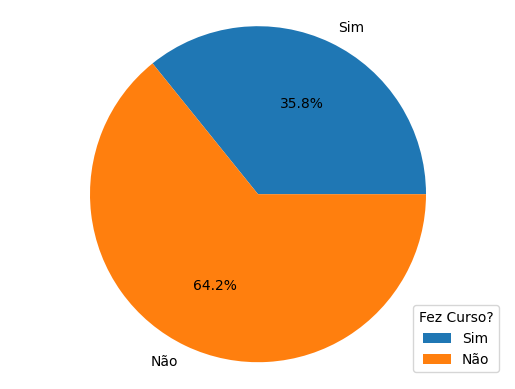

In [1373]:
#Estabelecendo um gráfico de pizza para entendimento que maior parte das pessoas não tiveram curso preparatório 
plt.pie(agrupado,labels= ['Sim','Não'],autopct='%1.1f%%')
plt.legend(title='Fez Curso?',loc="lower right")
plt.axis('equal')
plt.show()

In [1374]:
#Realizando o estudo das notas de acordo com algum padrão.
a= df.groupby('curso de preparacao')['nota em matematica'].mean()
b= df.groupby('curso de preparacao')['nota em leitura'].mean()
c= df.groupby('curso de preparacao')['nota em escrita'].mean()
display("Notas em matematica de acordo com cursos", a)
display("Notas em leitura de acordo com cursos", b)
display("Notas em escrita de acordo com cursos", c)
#Aqueles que fizeram curso completo de estudo alcançaram maiores notas nas provas

'Notas em matematica de acordo com cursos'

curso de preparacao
completed    69.695531
none         64.077882
Name: nota em matematica, dtype: float64

'Notas em leitura de acordo com cursos'

curso de preparacao
completed    73.893855
none         66.534268
Name: nota em leitura, dtype: float64

'Notas em escrita de acordo com cursos'

curso de preparacao
completed    74.418994
none         64.504673
Name: nota em escrita, dtype: float64

In [1375]:
#Achando os intervalos de confiança das notas para jogar nos gráficos

dpr= df.groupby('curso de preparacao')['nota em matematica'].std(ddof=1) #desvio padrao das notas por curso
ic_supm = a + (1.96*dpr/(1000**(1/2)))
ic_infm = a - (1.96*dpr/(1000**(1/2)))
print(ic_supm)
print(ic_infm)
erro_supm = ic_supm - a #distancia do erro ate a media para ir no grafico
erro_infm = a - ic_infm #distancia do erro ate a media para ir no grafico

dpr= df.groupby('curso de preparacao')['nota em leitura'].std(ddof=1) #desvio padrao das notas por curso
ic_supl = b + (1.96*dpr/(1000**(1/2)))
ic_infl = b - (1.96*dpr/(1000**(1/2)))
print(ic_supl)
print(ic_infl)
erro_supl = ic_supl - b #distancia do erro ate a media para ir no grafico
erro_infl = b - ic_infl #distancia do erro ate a media para ir no grafico

dpr= df.groupby('curso de preparacao')['nota em escrita'].std(ddof=1) #desvio padrao das notas por curso
ic_supe = c + (1.96*dpr/(1000**(1/2)))
ic_infe = c - (1.96*dpr/(1000**(1/2)))
print(ic_supe)
print(ic_infe)
erro_supe = ic_supe - c #distancia do erro ate a media para ir no grafico
erro_infe = c - ic_infe #distancia do erro ate a media para ir no grafico

curso de preparacao
completed    70.590822
none         65.019515
Name: nota em matematica, dtype: float64
curso de preparacao
completed    68.800239
none         63.136248
Name: nota em matematica, dtype: float64
curso de preparacao
completed    74.739171
none         67.430749
Name: nota em leitura, dtype: float64
curso de preparacao
completed    73.048539
none         65.637787
Name: nota em leitura, dtype: float64
curso de preparacao
completed    75.248006
none         65.434362
Name: nota em escrita, dtype: float64
curso de preparacao
completed    73.589983
none         63.574984
Name: nota em escrita, dtype: float64


C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\586849224.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='curso de preparacao', y='nota em matematica',palette=cores,order=ordem,ax=ax)


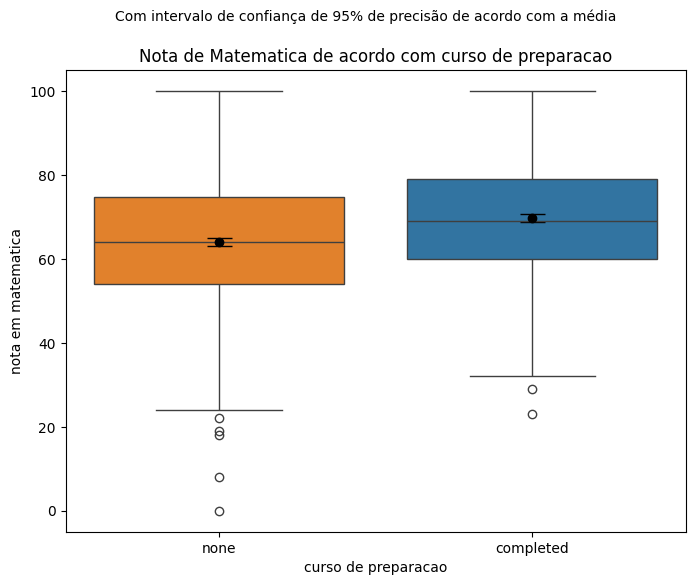

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\586849224.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='curso de preparacao', y='nota em leitura',palette=cores,order=ordem,ax=ax)


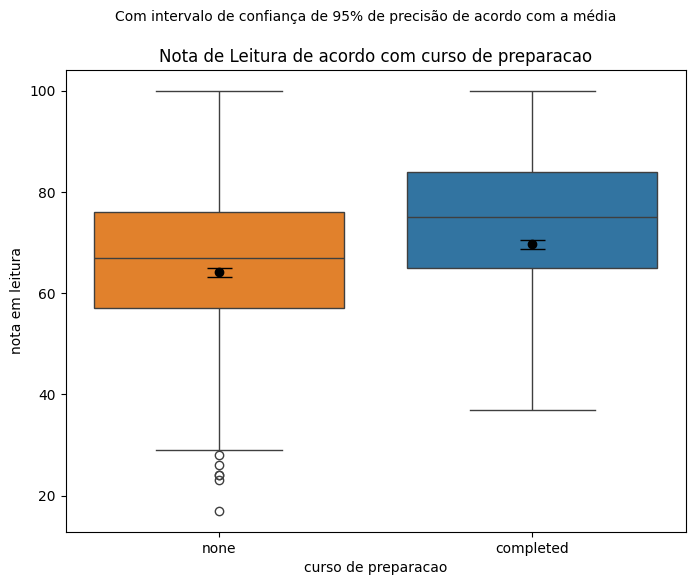

C:\Users\rodri\AppData\Local\Temp\ipykernel_14984\586849224.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  srn.boxplot(data=df, x='curso de preparacao', y='nota em escrita',palette=cores,order=ordem,ax=ax)


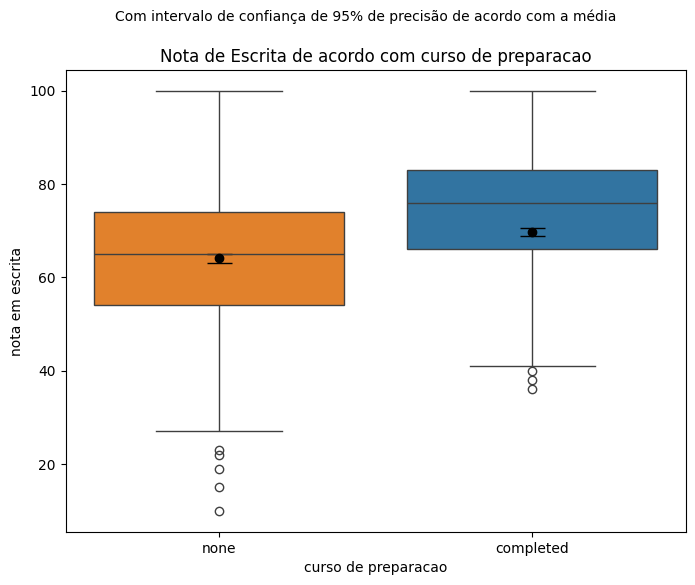

In [1376]:
ordem = ['none','completed']
cores = {
    'none':'#ff7f0e',
    'completed':'#1f77b4'
}

fig,ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='curso de preparacao', y='nota em matematica',palette=cores,order=ordem,ax=ax)
plt.title("Nota de Matematica de acordo com curso de preparacao")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, curso in enumerate(ordem): #percorre curso atraves de valores de i na ordem definida, x=0 -> none, x=1 -> completed e assim define o intervalo de confiança
    ax.errorbar(x=i, #curso no momento
                y=a[curso], #media do curso atual
                yerr=[[erro_infm[curso]],[erro_supm[curso]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='curso de preparacao', y='nota em leitura',palette=cores,order=ordem,ax=ax)
plt.title("Nota de Leitura de acordo com curso de preparacao")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, curso in enumerate(ordem): #percorre curso atraves de valores de i na ordem definida, x=0 -> none, x=1 -> completed e assim define o intervalo de confiança
    ax.errorbar(x=i, #curso no momento
                y=a[curso], #media do curso atual
                yerr=[[erro_infm[curso]],[erro_supm[curso]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

fig, ax = plt.subplots(figsize=(8,6))
srn.boxplot(data=df, x='curso de preparacao', y='nota em escrita',palette=cores,order=ordem,ax=ax)
plt.title("Nota de Escrita de acordo com curso de preparacao")
plt.suptitle("Com intervalo de confiança de 95% de precisão de acordo com a média", fontsize=10)
for i, curso in enumerate(ordem): #percorre curso atraves de valores de i na ordem definida, x=0 -> none, x=1 -> completed e assim define o intervalo de confiança
    ax.errorbar(x=i, #curso no momento
                y=a[curso], #media do curso atual
                yerr=[[erro_infm[curso]],[erro_supm[curso]]], #passando os valores da distância para criar o intervalo de confiança
                fmt='o', #formato do intervalo
                capsize=9, #tamanho da barra que fica nos polos
                color='black')#cores
plt.show()

In [1377]:
#analise geral das notas
agrupado = df.groupby(df['nota em matematica']).size()
agrupado

nota em matematica
0      1
8      1
18     1
19     1
22     1
      ..
96     3
97     6
98     3
99     3
100    7
Length: 81, dtype: int64

<Axes: xlabel='nota em matematica', ylabel='Count'>

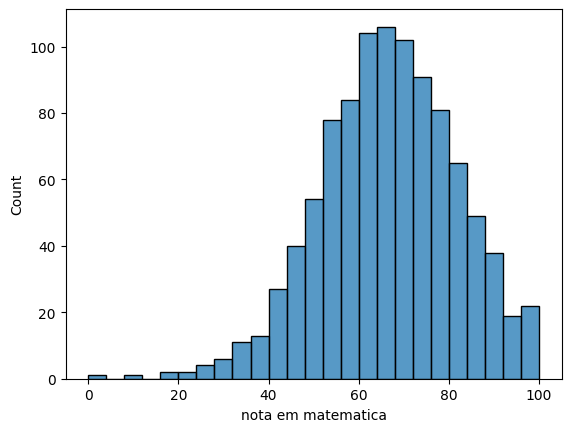

In [1378]:
#gráfico para entendimento da distribuição das notas
srn.histplot(df['nota em matematica'])

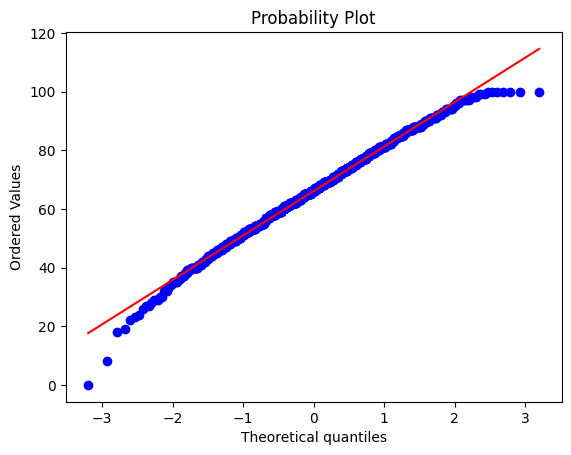

In [1379]:
#Vendos se o gráfico está nas normas padrão
fig, ax = plt.subplots()
stats.probplot(df['nota em matematica'], fit=True, plot=ax)
plt.show()

In [1380]:
# Valores de P acima de 0.5 representam dados confiaveis, valor de p muito baixo, indicaria não normalidade
# porém como têm diversos valores,1K de linhas o testo fica sensivel e acaba não sendo confiavel 
stats.shapiro(df['nota em matematica'])

ShapiroResult(statistic=np.float64(0.9931513872437832), pvalue=np.float64(0.00014545719606603633))

In [1381]:
#Realizando testes para melhor analise das notas

media = np.mean(df['nota em matematica'])
mediana = np.median(df['nota em matematica'])
moda = sts.mode(df['nota em matematica'])
quartis = np.quantile(df['nota em matematica'], [0 , 0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em matematica'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(66.089)

'A mediana e:'

np.float64(66.0)

'A moda e:'

65

'Os quartis são:'

array([  0.,  57.,  66.,  77., 100.])

'O desvio padrão e de:'

np.float64(15.16308009600945)

In [1382]:
#Criando quartis para ter uma noção da distribuição das notas e posteriormente uma probabilidade das mesmas
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)


'A chance de um valor entre 0% e 25%:'

np.float64(0.274)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.22399999999999998)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.266)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.22299999999999998)

In [1383]:
#Gerando uma analise geral das notas
agrupado = df.groupby(df['nota em leitura']).size()
agrupado

nota em leitura
17      1
23      1
24      2
26      1
28      1
       ..
95      8
96      4
97      5
99      3
100    17
Length: 72, dtype: int64

<Axes: xlabel='nota em leitura', ylabel='Count'>

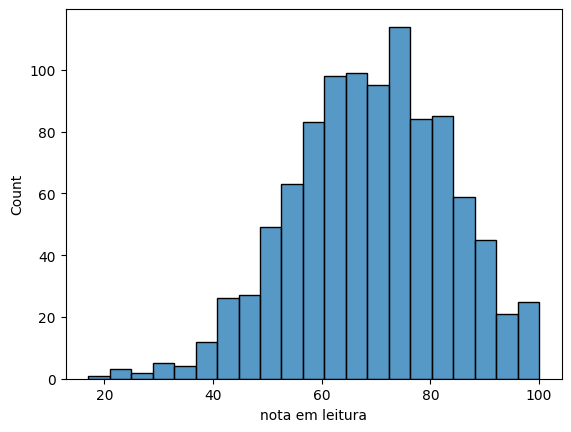

In [1384]:
#Grafico para entendimento da distribuição das notas
srn.histplot(df['nota em leitura'])

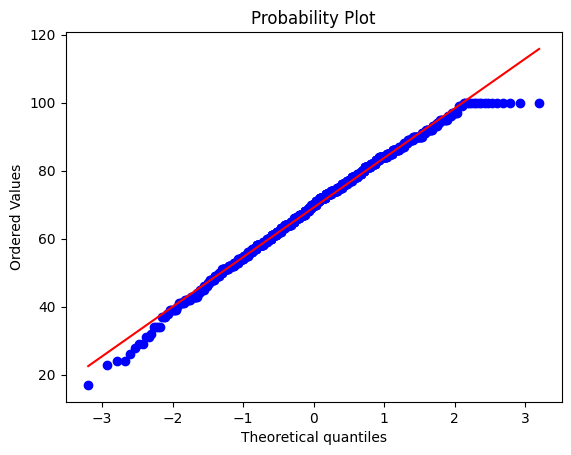

In [1385]:
#Vendos se o gráfico está nas normas padrão
fig, ax = plt.subplots()
stats.probplot(df['nota em leitura'], fit=True, plot=ax)
plt.show()

In [1386]:
# Valores de P acima de 0.5 representam dados confiaveis, valor de p muito baixo, indicaria não normalidade
# porém como têm diversos valores,1K de linhas o testo fica sensivel e acaba não sendo confiavel 
stats.shapiro(df['nota em leitura'])

ShapiroResult(statistic=np.float64(0.9929205131817913), pvalue=np.float64(0.00010554314738064095))

In [1387]:
#Realizando testes para melhor analise das notas
media = np.mean(df['nota em leitura'])
mediana = np.median(df['nota em leitura'])
moda = sts.mode(df['nota em leitura'])
quartis = np.quantile(df['nota em leitura'], [0 ,0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em leitura'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(69.169)

'A mediana e:'

np.float64(70.0)

'A moda e:'

72

'Os quartis são:'

array([ 17.,  59.,  70.,  79., 100.])

'O desvio padrão e de:'

np.float64(14.600191937252216)

In [1388]:
#Criando quartis para ter uma noção da distribuição das notas e posteriormente uma probabilidade das mesmas
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)

'A chance de um valor entre 0% e 25%:'

np.float64(0.243)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.28)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.22699999999999998)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.23299999999999998)

In [1389]:
#Gerando uma analise geral das notas
agrupado = df.groupby(df['nota em escrita']).size()
agrupado

nota em escrita
10      1
15      1
19      1
22      1
23      1
       ..
96      4
97      2
98      2
99      4
100    14
Length: 77, dtype: int64

<Axes: xlabel='nota em escrita', ylabel='Count'>

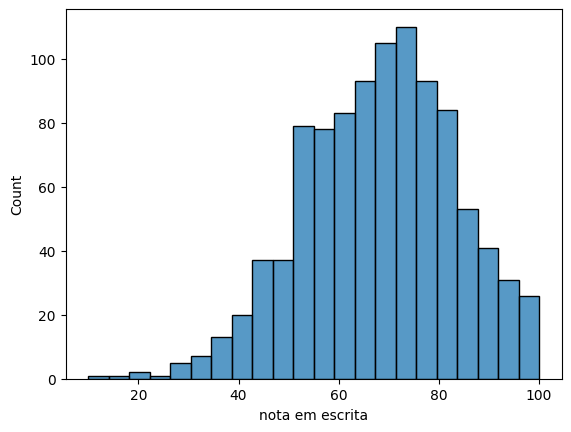

In [1390]:
#gerando grafico para entendimento melhor da distribuição das notas
srn.histplot(df['nota em escrita'])

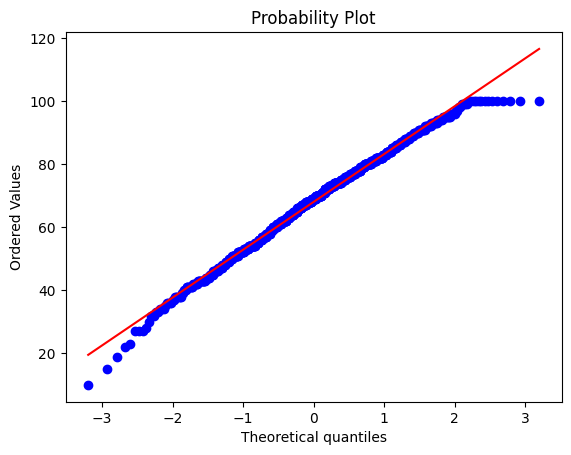

In [1391]:
#Vendos se o gráfico está nas normas padrão
fig, ax = plt.subplots()
stats.probplot(df['nota em escrita'], fit=True, plot=ax)
plt.show()

In [1392]:
# Valores de P acima de 0.5 representam dados confiaveis, valor de p muito baixo, indicaria não normalidade
# porém como têm diversos valores,1K de linhas o testo fica sensivel e acaba não sendo confiavel 
stats.shapiro(df['nota em escrita'])

ShapiroResult(statistic=np.float64(0.991964462962203), pvalue=np.float64(2.9215498810124692e-05))

In [1393]:
#Realizando testes para melhor analise das notas
media = np.mean(df['nota em escrita'])
mediana = np.median(df['nota em escrita'])
moda = sts.mode(df['nota em escrita'])
quartis = np.quantile(df['nota em escrita'], [0 , 0.25 , 0.50 , 0.75 , 1])
dp = np.std(df['nota em escrita'], ddof=1)
display('A media e:', media)
display('A mediana e:', mediana)
display('A moda e:',moda)
display('Os quartis são:', quartis)
display('O desvio padrão e de:',dp)

'A media e:'

np.float64(68.054)

'A mediana e:'

np.float64(69.0)

'A moda e:'

74

'Os quartis são:'

array([ 10.  ,  57.75,  69.  ,  79.  , 100.  ])

'O desvio padrão e de:'

np.float64(15.19565701086965)

In [1394]:
#Criando quartis para ter uma noção da distribuição das notas e posteriormente uma probabilidade das mesmas
#calculando probabilidade de cair valores nos primeiros 25%
p25 = norm.cdf(quartis[1],media,dp)
p25 = (p25).round(3)
display("A chance de um valor entre 0% e 25%:",p25)
#calculando probabilidade de cair valores entre 25%-50%
s25 = norm.cdf(quartis[2],media,dp)
s25 =(s25).round(3)
s25= s25 - p25
display("A chance de um valor entre os 25% e 50%:",s25)
#calculando probabilidade de cair valores entre 50%-75%
t25 = norm.cdf(quartis[3],media,dp)
t25 = (t25).round(3)
t25 = t25 - s25 - p25
display("A chance de um valor entre os 50% e 75%:",t25)
#calculando probabilidade de cair valores entre 75%-100%
q25 = norm.cdf(quartis[4],media,dp)
q25 = (q25).round(3)
q25 = q25 - t25 - s25 - p25
display("A chance de um valor entre os 75% e 1oo%:",q25)

'A chance de um valor entre 0% e 25%:'

np.float64(0.249)

'A chance de um valor entre os 25% e 50%:'

np.float64(0.276)

'A chance de um valor entre os 50% e 75%:'

np.float64(0.239)

'A chance de um valor entre os 75% e 1oo%:'

np.float64(0.21799999999999997)